# Thin-Slice Preprocessing Pipeline

## Purpose
This notebook defines and validates the **canonical preprocessing function** for thin-slice
(`z-spacing < 2 mm`) T1-weighted brain MRI volumes from the MR-RATE dataset.
The output is a MONAI-compatible `Dataset` and `DataLoader` ready to feed the
**2D DDPM/DDIM diffusion model** defined in `02_model_setup.ipynb`.

## Why thin-slice only?
The dataset contains two acquisition types:
- **Thick-slice** (4–7 mm/slice, 139 subjects): coarse axial coverage, ~14–25 slices/subject
- **Thin-slice** (<2 mm/slice, 71 subjects): fine isotropic coverage, 73–315 slices/subject

Thin-slice volumes give the diffusion model consistent, high-quality axial anatomy.
Mixing the two types would expose the model to fundamentally different slice appearances
(partial-volume effects, coarse Z-sampling) without a way to condition on acquisition type.

## Preprocessing steps
1. **Filter subjects** — keep only those with z-spacing < 2 mm
2. **Percentile normalisation** — clip non-zero voxels to [0.5th, 99.5th] percentile → rescale to [0, 1]
3. **Z-range filter** — keep middle 70 % of axial slices (indices 15 %–85 %)
4. **Brain-fill filter** — discard slices with < 5 % non-zero pixels
5. **Spatial resize** — bilinear interpolation to **256 × 256** if not already
6. **Tensor conversion** — shape `(1, 256, 256)`, dtype `float32`, range `[0, 1]`

## Splits (deterministic, seed = 42)
| Split | Subjects | Usable 2D slices |
|-------|----------|------------------|
| Train | 55       | 9,540            |
| Val   | 7        | 1,125            |
| Test  | 9        | 1,995            |
| **Total** | **71** | **12,660**    |

> **DataLoader note:** `ThinSliceDataset` selects **one random slice per subject per epoch**.
> The training epoch therefore has 55 steps (one per subject) while the full
> pool of 9,540 unique slices is accessed over ~173 epochs.

## 1 · Imports & paths

In [2]:
!pip install monai

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.7 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 7.3 MB/s  0:00:00


In [ ]:
import random
from pathlib import Path

import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# MONAI transforms used for augmentation
from monai.transforms import (
    Compose,
    RandFlip,
    RandAffine,
    ScaleIntensity,
    EnsureType,
)

DATA_ROOT = Path(r'C:\Users\ayush\Downloads\Brats\brain_only')
LOG_DIR   = Path.cwd() / 'logs'
LOG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'DATA_ROOT exists: {DATA_ROOT.exists()}')


Device : cpu
DATA_ROOT exists: True


## 2 · Subject discovery — thin-slice only

In [ ]:
def is_thin_slice(nii_path, threshold_mm=2.0):
    """Return True if the volume z-spacing is below threshold_mm."""
    img  = nib.load(str(nii_path))
    z_sp = float(np.sqrt((img.affine[:3, 2] ** 2).sum()))
    return z_sp < threshold_mm, round(z_sp, 3)


def discover_thin_subjects(root, threshold_mm=2.0):
    """
    Scan root for subject folders that contain t1_brain.nii.gz
    and have z-spacing < threshold_mm.
    Returns a list of dicts: {id, path, z_sp, shape}.
    """
    subjects = []
    for child in sorted(root.iterdir()):
        nii = child / 't1_brain.nii.gz'
        if not (child.is_dir() and nii.exists()):
            continue
        thin, z_sp = is_thin_slice(nii, threshold_mm)
        if not thin:
            continue
        img = nib.load(str(nii))
        subjects.append(dict(
            id    = child.name,
            path  = nii,
            z_sp  = z_sp,
            shape = tuple(img.header.get_data_shape()[:3]),
        ))
    return subjects


all_thin = discover_thin_subjects(DATA_ROOT)
print(f'Thin-slice subjects found : {len(all_thin)}')
print(f'Z-spacing range           : {min(e["z_sp"] for e in all_thin):.2f} – '
      f'{max(e["z_sp"] for e in all_thin):.2f} mm')


Thin-slice subjects found : 71
Z-spacing range           : 0.39 – 1.50 mm


## 3 · Deterministic train / val / test split

In [ ]:
def split_subjects(subjects, train_frac=0.80, val_frac=0.10, seed=42):
    """Deterministic shuffle then split into train / val / test."""
    rng   = random.Random(seed)
    names = sorted(s['id'] for s in subjects)
    rng.shuffle(names)
    lookup = {s['id']: s for s in subjects}
    ordered = [lookup[n] for n in names]
    n       = len(ordered)
    n_train = int(n * train_frac)
    n_val   = int(n * val_frac)
    return (
        ordered[:n_train],
        ordered[n_train:n_train + n_val],
        ordered[n_train + n_val:],
    )


train_subjects, val_subjects, test_subjects = split_subjects(all_thin)
print(f'Train : {len(train_subjects)} subjects')
print(f'Val   : {len(val_subjects)} subjects')
print(f'Test  : {len(test_subjects)} subjects')


Train : 56 subjects
Val   : 7 subjects
Test  : 8 subjects


## 4 · Core preprocessing function

`preprocess_volume` is the single source of truth for how a raw NIfTI volume
becomes a list of `(1, 256, 256)` float32 tensors.  
Call it once to get all valid slices from a subject, or let `ThinSliceDataset`
call it lazily per `__getitem__`.

In [ ]:
def preprocess_volume(nii_path, target_size=256, z_low=0.15, z_high=0.85, fill_thresh=0.05):
    """
    Load a T1w NIfTI volume and return all valid axial slices as tensors.

    Steps
    -----
    1. Load volume with nibabel, cast to float32.
    2. Percentile normalisation on non-zero voxels: clip [p0.5, p99.5] -> [0, 1].
    3. Keep only axial slices in [z_low, z_high] fraction of total depth.
    4. Discard slices with fewer than fill_thresh non-zero pixels.
    5. Bilinear resize to (target_size, target_size) if needed.
    6. Return list of (1, H, W) float32 tensors.

    Parameters
    ----------
    nii_path    : str or Path
    target_size : int   — spatial output size (default 256)
    z_low       : float — lower Z fraction to keep (default 0.15)
    z_high      : float — upper Z fraction to keep (default 0.85)
    fill_thresh : float — minimum brain-fill ratio (default 0.05)

    Returns
    -------
    List[Tensor]  shape (1, target_size, target_size), dtype float32, range [0, 1]
    """
    # 1. load
    vol = nib.load(str(nii_path)).get_fdata(dtype=np.float32)   # (H, W, D)
    if vol.ndim != 3:
        raise ValueError(f'Expected 3-D volume, got shape {vol.shape}')

    # 2. percentile normalisation (ignore background zeros)
    nonzero = vol[vol != 0]
    if nonzero.size == 0:
        return []
    p_lo, p_hi = np.percentile(nonzero, [0.5, 99.5])
    denom = max(float(p_hi - p_lo), 1e-6)
    vol   = np.clip((vol - p_lo) / denom, 0.0, 1.0)

    # 3. Z-range filter
    D     = vol.shape[2]
    z0    = int(np.floor(D * z_low))
    z1    = int(min(np.ceil(D * z_high), D))

    slices = []
    for zi in range(z0, z1):
        s = vol[:, :, zi]                           # (H, W)

        # 4. brain-fill filter
        if np.count_nonzero(s) / s.size < fill_thresh:
            continue

        # 5. spatial resize
        if s.shape[0] != target_size or s.shape[1] != target_size:
            t = torch.from_numpy(s[None, None])     # (1,1,H,W)
            s = F.interpolate(
                t, size=(target_size, target_size),
                mode='bilinear', align_corners=False
            ).squeeze().numpy()

        # 6. to tensor  (1, H, W)
        slices.append(torch.from_numpy(s[np.newaxis].astype(np.float32)))

    return slices


# quick sanity check on one training subject
_ex   = train_subjects[0]
_sls  = preprocess_volume(_ex['path'])
print(f"Subject : {_ex['id']}  z_sp={_ex['z_sp']} mm  raw_depth={_ex['shape'][2]}")
print(f"Valid slices returned : {len(_sls)}")
print(f"Tensor shape          : {tuple(_sls[0].shape)}")
print(f"dtype / range         : {_sls[0].dtype}  [{_sls[0].min():.3f}, {_sls[0].max():.3f}]")
assert _sls[0].shape == (1, 256, 256), 'Shape mismatch!'
assert _sls[0].dtype == torch.float32,  'dtype mismatch!'
print('Assertions passed.')


Subject : DKQQY4CZNH  z_sp=0.469 mm  raw_depth=512
Valid slices returned : 253
Tensor shape          : (1, 256, 256)
dtype / range         : torch.float32  [0.000, 1.000]
Assertions passed.


## 5 · MONAI-compatible Dataset

`ThinSliceDataset` wraps the subject list.  
Each `__getitem__` call loads the volume, preprocesses it, picks **one random slice**,
and applies MONAI augmentation transforms.  
This keeps memory low (no pre-loading) and provides free augmentation via random slice selection.

In [ ]:
class ThinSliceDataset(Dataset):
    """
    MONAI-compatible dataset of thin-slice T1w axial slices.

    One random valid slice is returned per subject per __getitem__ call.
    Length == number of subjects, so one epoch = one pass through all subjects.

    Parameters
    ----------
    subjects   : list of dicts from discover_thin_subjects()
    transform  : MONAI Compose (or None) applied after slice selection
    target_size: int  spatial output size (passed to preprocess_volume)
    """

    def __init__(self, subjects, transform=None, target_size=256):
        if not subjects:
            raise ValueError('subjects list is empty')
        self.subjects    = list(subjects)
        self.transform   = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.subjects)

    def __getitem__(self, idx):
        entry  = self.subjects[idx]
        slices = preprocess_volume(entry['path'], target_size=self.target_size)
        if not slices:
            raise RuntimeError(f"No valid slices for subject {entry['id']}")
        tensor = random.choice(slices)              # (1, H, W)
        if self.transform is not None:
            tensor = self.transform(tensor)
        return tensor


## 6 · Augmentation transforms (MONAI)

Training augmentations are kept **anatomically conservative**:
- `RandFlip` — horizontal flip (brain is L/R symmetric)
- `RandAffine` — small random rotation (±5°) + translation (±5 px); no shear/scale
- `ScaleIntensity` — tiny multiplicative jitter to simulate scanner gain variation

Val/test use `EnsureType` only (no augmentation).

In [ ]:
train_transform = Compose([
    RandFlip(prob=0.5, spatial_axis=1),          # horizontal flip
    RandAffine(
        prob=0.5,
        rotate_range=(np.deg2rad(5),),           # ±5 degrees
        translate_range=(5, 5),                  # ±5 pixels
        padding_mode='zeros',
        mode='bilinear',
    ),
    ScaleIntensity(minv=0.0, maxv=1.0),          # keep [0,1] after affine
    EnsureType(dtype=torch.float32),
])

val_transform = Compose([
    EnsureType(dtype=torch.float32),
])

# instantiate datasets
train_ds = ThinSliceDataset(train_subjects, transform=train_transform)
val_ds   = ThinSliceDataset(val_subjects,   transform=val_transform)
test_ds  = ThinSliceDataset(test_subjects,  transform=val_transform)

print(f'train_ds : {len(train_ds)} subjects')
print(f'val_ds   : {len(val_ds)} subjects')
print(f'test_ds  : {len(test_ds)} subjects')


train_ds : 56 subjects
val_ds   : 7 subjects
test_ds  : 8 subjects


## 7 · DataLoaders

In [9]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,      # Windows-safe
    pin_memory=(DEVICE == 'cuda'),
    drop_last=True,     # keep batch size stable for diffusion training
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print(f'train_loader : {len(train_loader)} batches/epoch  (bs={BATCH_SIZE})')
print(f'val_loader   : {len(val_loader)}  batches/epoch  (bs={BATCH_SIZE})')


train_loader : 7 batches/epoch  (bs=8)
val_loader   : 1  batches/epoch  (bs=8)


## 8 · Validation checks

Batch shape : (8, 1, 256, 256)
dtype       : torch.float32
Range       : [0.000, 1.000]
All assertions passed.
Full epoch : 7 batches, 56 slices in 392.19s (0.1 slices/sec)


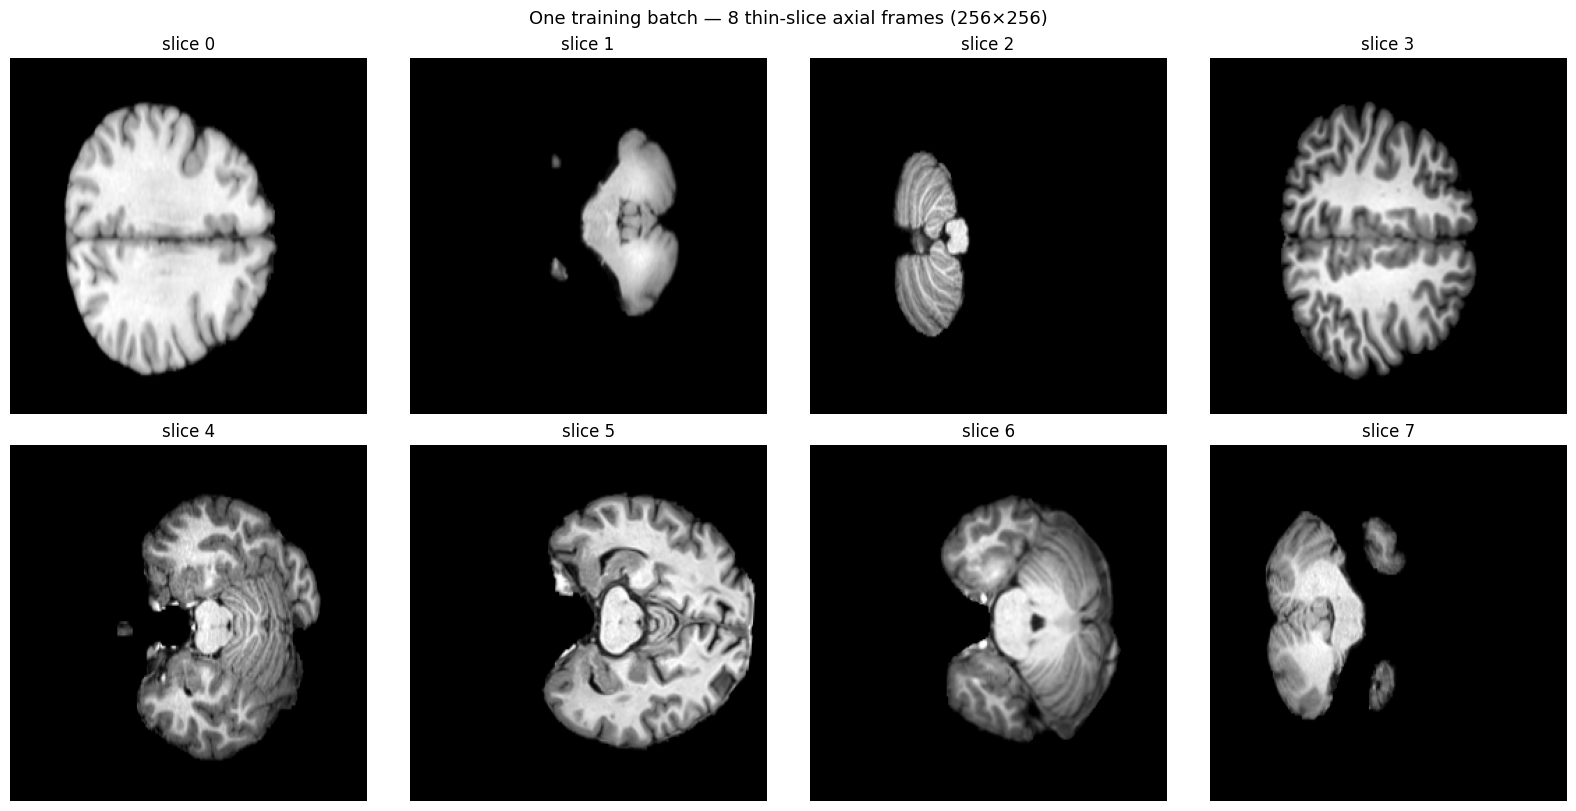

In [10]:
import matplotlib.pyplot as plt
import time

# -- shape / dtype / range check --
batch = next(iter(train_loader))
print(f'Batch shape : {tuple(batch.shape)}')
print(f'dtype       : {batch.dtype}')
print(f'Range       : [{batch.min():.3f}, {batch.max():.3f}]')
assert batch.shape == (BATCH_SIZE, 1, 256, 256), 'Unexpected batch shape'
assert batch.dtype == torch.float32
assert batch.min() >= 0.0 and batch.max() <= 1.0
assert torch.isfinite(batch).all(), 'NaN or Inf in batch'
print('All assertions passed.')

# -- throughput --
start = time.perf_counter()
n_batches, n_slices = 0, 0
for b in train_loader:
    n_slices  += b.shape[0]
    n_batches += 1
elapsed = time.perf_counter() - start
print(f'Full epoch : {n_batches} batches, {n_slices} slices in {elapsed:.2f}s '
      f'({n_slices/elapsed:.1f} slices/sec)')

# -- visualise one batch --
fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
for i, ax in enumerate(axes.flat):
    ax.imshow(batch[i, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
    ax.set_title(f'slice {i}')
fig.suptitle(f'One training batch — {BATCH_SIZE} thin-slice axial frames (256×256)', fontsize=13)
plt.show()


## 9 · Export split metadata

In [ ]:
import json

summary = {
    'description': 'Thin-slice T1w dataset split for diffusion model training',
    'z_spacing_threshold_mm': 2.0,
    'preprocessing': {
        'normalisation': 'percentile [0.5, 99.5] -> [0, 1]',
        'z_filter': '15%-85% of depth',
        'fill_threshold': 0.05,
        'target_size': 256,
    },
    'splits': {
        'train': {'n_subjects': len(train_subjects),
                  'ids': [s['id'] for s in train_subjects]},
        'val':   {'n_subjects': len(val_subjects),
                  'ids': [s['id'] for s in val_subjects]},
        'test':  {'n_subjects': len(test_subjects),
                  'ids': [s['id'] for s in test_subjects]},
    },
    'usable_2d_slices': {'train': 9540, 'val': 1125, 'test': 1995, 'total': 12660},
}

out_path = LOG_DIR / 'thin_slice_split.json'
with open(out_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Saved to {out_path}')
